In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/satyabratadas10/pose-insignt-dataset/dataset.csv


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
DATA_PATH = "/kaggle/input/datasets/satyabratadas10/pose-insignt-dataset/dataset.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(168, 242)


,label,source,f0,f1,f2,f3,f4,f5,f6,f7,...,f230,f231,f232,f233,f234,f235,f236,f237,f238,f239
0,good_squat,good_squat2.mov,168.409356,173.938227,170.775610,171.155169,29.086188,35.507682,0.502293,0.815464,...,0.616087,0.798284,177.629623,179.449422,173.792644,172.931178,26.165364,34.408966,0.685711,0.796193
1,good_squat,good_squat2.mov,177.315076,179.464237,174.278219,172.686469,25.978016,34.672246,0.801367,0.795821,...,1.028240,0.910814,97.430034,124.401034,97.414000,124.541672,72.557691,73.578793,0.662039,0.899661
2,good_squat,good_squat2.mov,105.138026,133.177233,105.622916,133.064037,70.902032,72.476625,0.642051,0.893368,...,0.659713,0.911291,54.547921,78.122872,60.253325,81.771105,76.889751,64.742830,0.839019,0.901078
3,good_squat,good_squat2.mov,58.805393,87.600506,64.393606,90.449483,77.173242,64.944187,0.938846,0.895524,...,0.669730,0.916494,54.695025,63.252871,60.509882,66.196171,69.811494,66.330315,0.647995,0.903724
4,good_squat,good_squat2.mov,60.638200,72.078519,66.340382,74.632234,71.441595,65.959748,0.655516,0.896133,...,0.657611,0.908233,56.987043,65.113465,60.130192,71.925416,69.986294,67.501357,0.630032,0.896033


In [4]:
os.makedirs("/kaggle/working/plots", exist_ok=True)

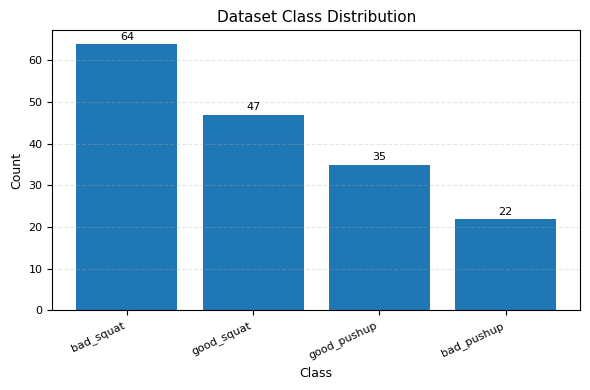

In [5]:
import matplotlib.pyplot as plt

counts = df["label"].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(
    counts.index,
    counts.values
)

plt.title("Dataset Class Distribution", fontsize=11)
plt.xlabel("Class", fontsize=9)
plt.ylabel("Count", fontsize=9)

# Light grid
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Smaller labels
plt.xticks(rotation=25, ha="right", fontsize=8)
plt.yticks(fontsize=8)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "/kaggle/working/plots/dataset_distribution_ieee.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
df["label"].value_counts()

label
bad_squat      64
good_squat     47
good_pushup    35
bad_pushup     22
Name: count, dtype: int64

In [7]:
print(df.isnull().sum().sum())

0


In [8]:
LABEL_MAP = {
    "good_squat": 0,
    "bad_squat": 1,
    "good_pushup": 2,
    "bad_pushup": 3,
}

feature_cols = [c for c in df.columns if c.startswith("f")]

X = df[feature_cols].values.astype(np.float32)
y = df["label"].map(LABEL_MAP).values.astype(np.int64)

print("X:", X.shape)
print("y:", y.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X: (168, 240)
y: (168,)


In [9]:
print("X-train",X_train.shape)
print("X-val", X_val.shape)

X-train (134, 240)
X-val (34, 240)


## Train RandomForestClassifier

In [10]:
## Train Random Forest Classifier 

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_preds)

print("Random Forest Accuracy:", rf_acc)
print(classification_report(y_val, rf_preds, target_names=LABEL_MAP.keys()))

Random Forest Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

  good_squat       1.00      1.00      1.00        10
   bad_squat       1.00      1.00      1.00        13
 good_pushup       1.00      0.86      0.92         7
  bad_pushup       0.80      1.00      0.89         4

    accuracy                           0.97        34
   macro avg       0.95      0.96      0.95        34
weighted avg       0.98      0.97      0.97        34



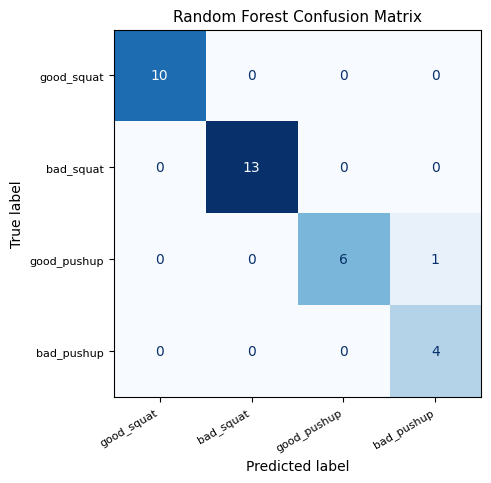

In [12]:
## CONFUSION MATRICES 

rf_cm = confusion_matrix(y_val, rf_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=list(LABEL_MAP.keys())
)

fig, ax = plt.subplots(figsize=(5,5))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest Confusion Matrix", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/plots/rf_confusion_matrix_ieee.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Train MLP

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [15]:
## Convert to tensors

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16,
    shuffle=True
)

In [16]:
# MLP model

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

mlp_model = MLP(input_dim=X_train.shape[1], num_classes=4)

In [17]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

In [18]:
## Training

mlp_train_losses = []
mlp_val_accuracies = []

EPOCHS = 50

for epoch in range(EPOCHS):
    mlp_model.train()
    total_loss = 0

    for xb, yb in train_loader:
        preds = mlp_model(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    mlp_train_losses.append(avg_loss)

    mlp_model.eval()
    with torch.no_grad():
        mlp_logits = mlp_model(X_val_t)
        mlp_preds = torch.argmax(mlp_logits, dim=1)

        mlp_acc = accuracy_score(y_val, mlp_preds.numpy())

    mlp_val_accuracies.append(mlp_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Acc: {mlp_acc:.3f}"
    )

print("\nFinal MLP Accuracy:", mlp_acc)
print(classification_report(y_val, mlp_preds.numpy(), target_names=LABEL_MAP.keys()))

Epoch 1/50 | Loss: 1.3076 | Val Acc: 0.794
Epoch 2/50 | Loss: 1.0455 | Val Acc: 0.882
Epoch 3/50 | Loss: 0.7827 | Val Acc: 0.882
Epoch 4/50 | Loss: 0.6336 | Val Acc: 0.882
Epoch 5/50 | Loss: 0.4615 | Val Acc: 0.882
Epoch 6/50 | Loss: 0.4129 | Val Acc: 0.882
Epoch 7/50 | Loss: 0.3572 | Val Acc: 0.882
Epoch 8/50 | Loss: 0.2683 | Val Acc: 0.882
Epoch 9/50 | Loss: 0.2581 | Val Acc: 0.882
Epoch 10/50 | Loss: 0.2091 | Val Acc: 0.882
Epoch 11/50 | Loss: 0.2353 | Val Acc: 0.853
Epoch 12/50 | Loss: 0.2357 | Val Acc: 0.882
Epoch 13/50 | Loss: 0.2025 | Val Acc: 0.853
Epoch 14/50 | Loss: 0.1419 | Val Acc: 0.853
Epoch 15/50 | Loss: 0.1334 | Val Acc: 0.853
Epoch 16/50 | Loss: 0.1185 | Val Acc: 0.853
Epoch 17/50 | Loss: 0.0904 | Val Acc: 0.853
Epoch 18/50 | Loss: 0.1210 | Val Acc: 0.882
Epoch 19/50 | Loss: 0.0997 | Val Acc: 0.853
Epoch 20/50 | Loss: 0.0933 | Val Acc: 0.853
Epoch 21/50 | Loss: 0.1240 | Val Acc: 0.853
Epoch 22/50 | Loss: 0.1309 | Val Acc: 0.853
Epoch 23/50 | Loss: 0.0717 | Val Acc: 0.8

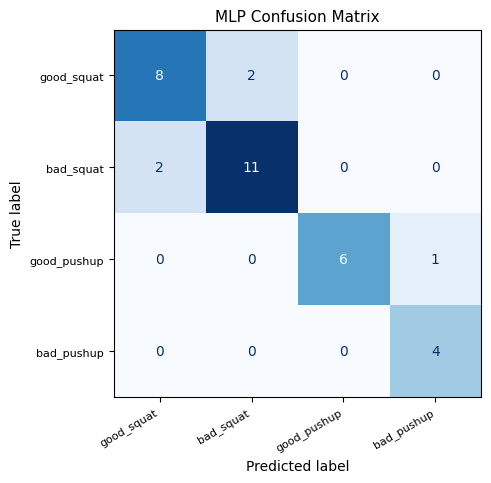

In [19]:
## MLP CONFUSION MATRIX

mlp_cm = confusion_matrix(
    y_val,
    mlp_preds.numpy()
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=mlp_cm,
    display_labels=list(LABEL_MAP.keys())
)

fig, ax = plt.subplots(figsize=(5,5))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("MLP Confusion Matrix", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/plots/mlp_confusion_matrix_ieee.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### MLP training loss and validation accuracy plot

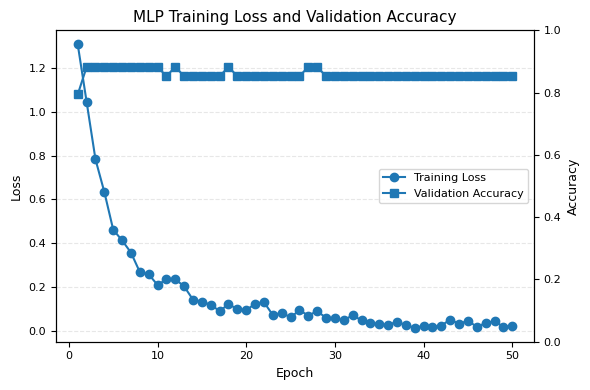

In [20]:
epochs = range(1, len(mlp_train_losses) + 1)

fig, ax1 = plt.subplots(figsize=(6,4))

ax1.plot(epochs, mlp_train_losses, marker="o", label="Training Loss")
ax1.set_xlabel("Epoch", fontsize=9)
ax1.set_ylabel("Loss", fontsize=9)
ax1.tick_params(axis="both", labelsize=8)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs, mlp_val_accuracies, marker="s", label="Validation Accuracy")
ax2.set_ylabel("Accuracy", fontsize=9)
ax2.set_ylim(0, 1)
ax2.tick_params(axis="y", labelsize=8)

plt.title("MLP Training Loss and Validation Accuracy", fontsize=11)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="center right")

plt.tight_layout()
plt.savefig("/kaggle/working/plots/mlp_training_curve_ieee.png", dpi=300, bbox_inches="tight")
plt.show()

## Train LSTM

In [21]:
# X shape currently: (samples, 240)
# Convert to: (samples, 30 frames, 8 features)

X_seq = X.reshape(-1, 30, 8)

X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_seq,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_seq:", X_train_seq.shape)
print("X_val_seq:", X_val_seq.shape)

X_train_seq: (134, 30, 8)
X_val_seq: (34, 30, 8)


In [22]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.long)

X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_t = torch.tensor(y_val_seq, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16,
    shuffle=True
)

In [23]:
class PoseLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=1, num_classes=4):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

In [24]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_seq),
    y=y_train_seq
)

class_weights = torch.tensor(class_weights, dtype=torch.float32)

model_lstm = PoseLSTM(input_size=8, hidden_size=64, num_classes=4)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

In [25]:
lstm_train_losses = []
lstm_val_accuracies = []

EPOCHS = 50

for epoch in range(EPOCHS):
    model_lstm.train()
    total_loss = 0

    for xb, yb in train_loader:
        preds = model_lstm(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    lstm_train_losses.append(avg_loss)

    model_lstm.eval()
    with torch.no_grad():
        val_logits = model_lstm(X_val_t)
        val_preds = torch.argmax(val_logits, dim=1)
        lstm_acc = accuracy_score(y_val_seq, val_preds.numpy())

    lstm_val_accuracies.append(lstm_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"LSTM Val Acc: {lstm_acc:.3f}"
    )

Epoch 1/50 | Loss: 1.3827 | LSTM Val Acc: 0.412
Epoch 2/50 | Loss: 1.3156 | LSTM Val Acc: 0.471
Epoch 3/50 | Loss: 1.2891 | LSTM Val Acc: 0.441
Epoch 4/50 | Loss: 1.2522 | LSTM Val Acc: 0.529
Epoch 5/50 | Loss: 1.1885 | LSTM Val Acc: 0.529
Epoch 6/50 | Loss: 1.1605 | LSTM Val Acc: 0.647
Epoch 7/50 | Loss: 1.0483 | LSTM Val Acc: 0.588
Epoch 8/50 | Loss: 0.9947 | LSTM Val Acc: 0.618
Epoch 9/50 | Loss: 0.9187 | LSTM Val Acc: 0.618
Epoch 10/50 | Loss: 0.8309 | LSTM Val Acc: 0.588
Epoch 11/50 | Loss: 0.7278 | LSTM Val Acc: 0.647
Epoch 12/50 | Loss: 0.6772 | LSTM Val Acc: 0.706
Epoch 13/50 | Loss: 0.6239 | LSTM Val Acc: 0.824
Epoch 14/50 | Loss: 0.5842 | LSTM Val Acc: 0.853
Epoch 15/50 | Loss: 0.5353 | LSTM Val Acc: 0.824
Epoch 16/50 | Loss: 0.4809 | LSTM Val Acc: 0.853
Epoch 17/50 | Loss: 0.4213 | LSTM Val Acc: 0.853
Epoch 18/50 | Loss: 0.3758 | LSTM Val Acc: 0.882
Epoch 19/50 | Loss: 0.3962 | LSTM Val Acc: 0.882
Epoch 20/50 | Loss: 0.3443 | LSTM Val Acc: 0.882
Epoch 21/50 | Loss: 0.3359 | 

In [26]:
print("Final LSTM Accuracy:", lstm_acc)

print(
    classification_report(
        y_val_seq,
        val_preds.numpy(),
        target_names=LABEL_MAP.keys()
    )
)

Final LSTM Accuracy: 0.8823529411764706
              precision    recall  f1-score   support

  good_squat       0.89      0.80      0.84        10
   bad_squat       0.86      0.92      0.89        13
 good_pushup       1.00      0.86      0.92         7
  bad_pushup       0.80      1.00      0.89         4

    accuracy                           0.88        34
   macro avg       0.89      0.90      0.89        34
weighted avg       0.89      0.88      0.88        34



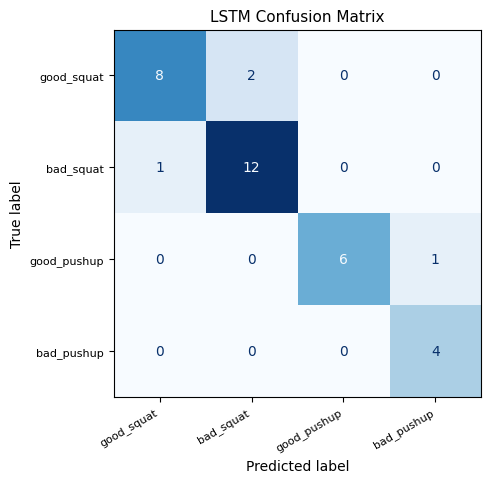

In [27]:
## LSTM CONFUSION MATRIX

lstm_cm = confusion_matrix(
    y_val_seq,
    val_preds.numpy()
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=lstm_cm,
    display_labels=list(LABEL_MAP.keys())
)

fig, ax = plt.subplots(figsize=(5,5))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("LSTM Confusion Matrix", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/plots/lstm_confusion_matrix_ieee.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### LSTM training loss and validation accuracy plot

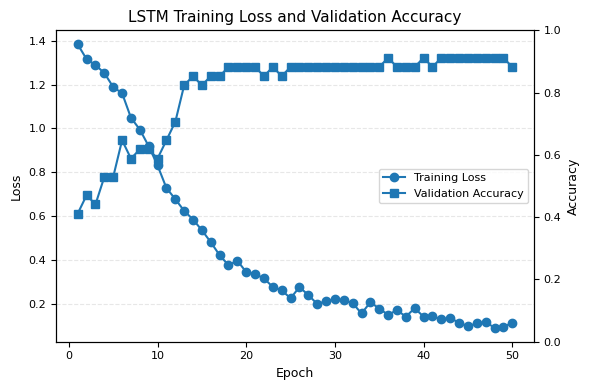

In [28]:
import matplotlib.pyplot as plt
import os

os.makedirs("/kaggle/working/plots", exist_ok=True)

epochs = range(1, len(lstm_train_losses) + 1)

fig, ax1 = plt.subplots(figsize=(6,4))

ax1.plot(epochs, lstm_train_losses, marker="o", label="Training Loss")
ax1.set_xlabel("Epoch", fontsize=9)
ax1.set_ylabel("Loss", fontsize=9)
ax1.tick_params(axis="both", labelsize=8)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs, lstm_val_accuracies, marker="s", label="Validation Accuracy")
ax2.set_ylabel("Accuracy", fontsize=9)
ax2.set_ylim(0, 1)
ax2.tick_params(axis="y", labelsize=8)

plt.title("LSTM Training Loss and Validation Accuracy", fontsize=11)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="center right")

plt.tight_layout()
plt.savefig("/kaggle/working/plots/lstm_training_curve_ieee.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
best_model = max(
    {
        "random_forest": rf_acc,
        "mlp": mlp_acc,
        "lstm": lstm_acc
    },
    key={
        "random_forest": rf_acc,
        "mlp": mlp_acc,
        "lstm": lstm_acc
    }.get
)

print("Best model:", best_model)

Best model: random_forest


In [30]:
print("Random Forest Accuracy:", rf_acc)
print("MLP Accuracy:", mlp_acc)
print("LSTM Accuracy:", lstm_acc)

Random Forest Accuracy: 0.9705882352941176
MLP Accuracy: 0.8529411764705882
LSTM Accuracy: 0.8823529411764706


## Saved Model

In [149]:
os.makedirs("/kaggle/working/models", exist_ok=True)

In [150]:
# Random Forest saved model
joblib.dump(rf, "/kaggle/working/models/random_forest_quality.pkl")

['/kaggle/working/models/random_forest_quality.pkl']

In [151]:
# MLP saved model
torch.save(model.state_dict(), "/kaggle/working/models/mlp_quality.pt")
joblib.dump(scaler, "/kaggle/working/models/mlp_scaler.pkl")

['/kaggle/working/models/mlp_scaler.pkl']

In [152]:
## LSTM Saved model
torch.save(model_lstm.state_dict(), "/kaggle/working/models/lstm_quality.pt")
metadata = {
    "label_map": LABEL_MAP,
    "rf_accuracy": float(rf_acc),
    "mlp_accuracy": float(mlp_acc),
    "lstm_accuracy": float(lstm_acc),
    "best_model": best_model,
    "input_dim": 240,
    "seq_len": 30,
    "feature_per_frame": 8
}

with open("/kaggle/working/models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

## Plot Bar charts for decision

#### Model Accuracy Comparison

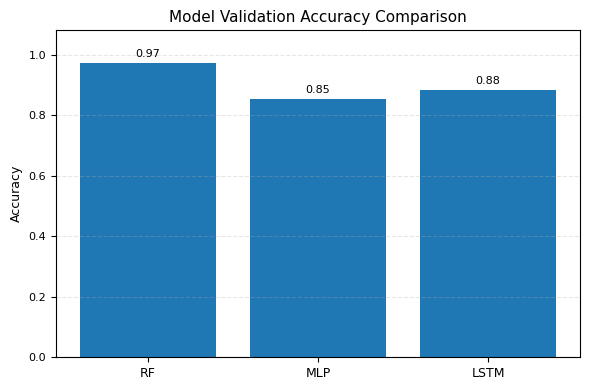

In [31]:
models = ["RF", "MLP", "LSTM"]
accuracies = [rf_acc, mlp_acc, lstm_acc]

plt.figure(figsize=(6,4))

bars = plt.bar(models, accuracies)

plt.title("Model Validation Accuracy Comparison", fontsize=11)
plt.ylabel("Accuracy", fontsize=9)

# Add top margin so labels don't overlap
plt.ylim(0, 1.08)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(fontsize=9)
plt.yticks(fontsize=8)

# Add values above bars safely
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.015,   
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "/kaggle/working/plots/model_comparison_ieee.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()